In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


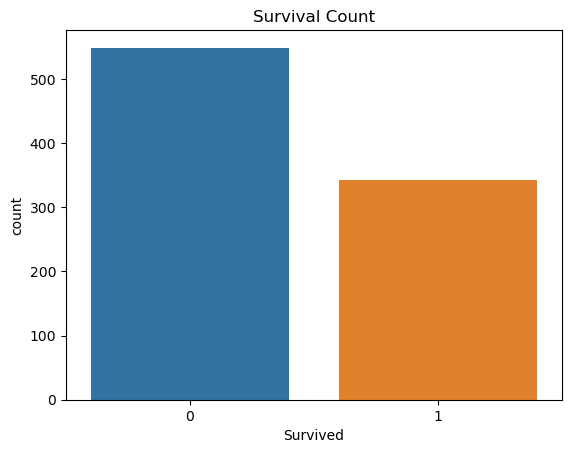

In [9]:
sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.show()

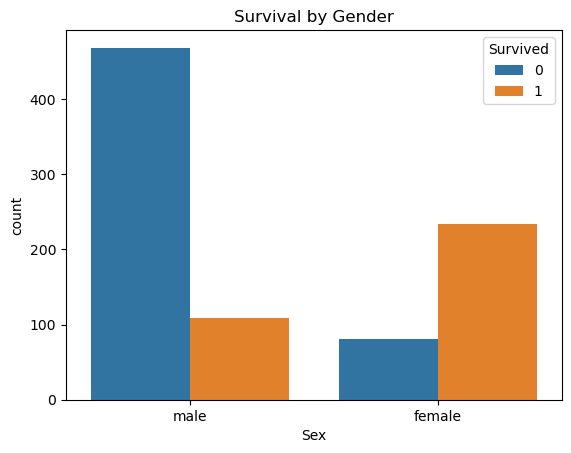

In [10]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.show()

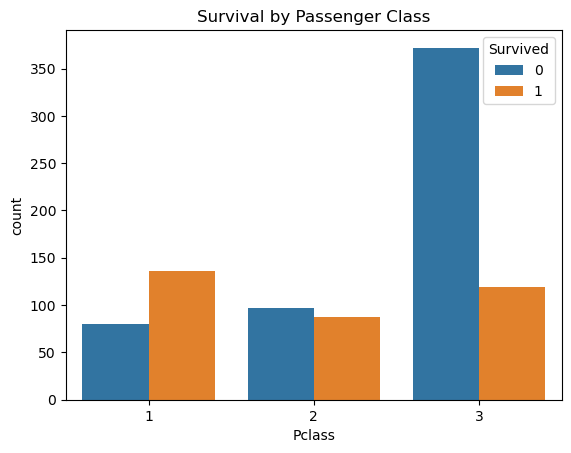

In [11]:
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.show()

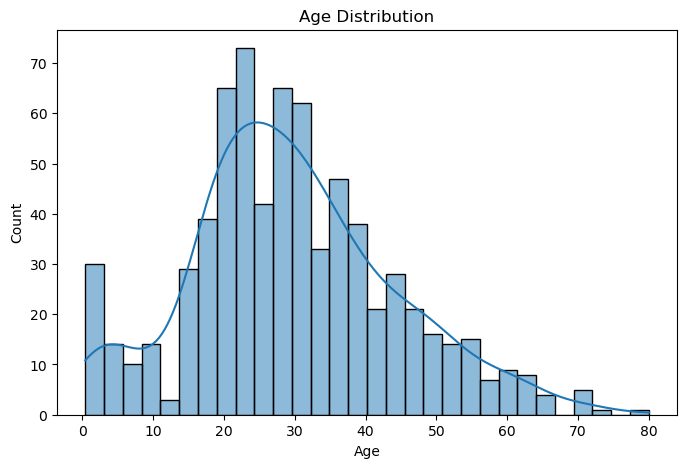

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

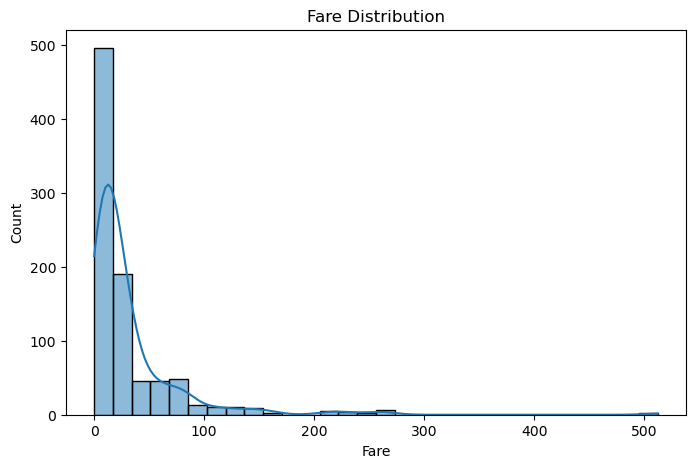

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=30, kde=True)

plt.title("Fare Distribution")

plt.show()

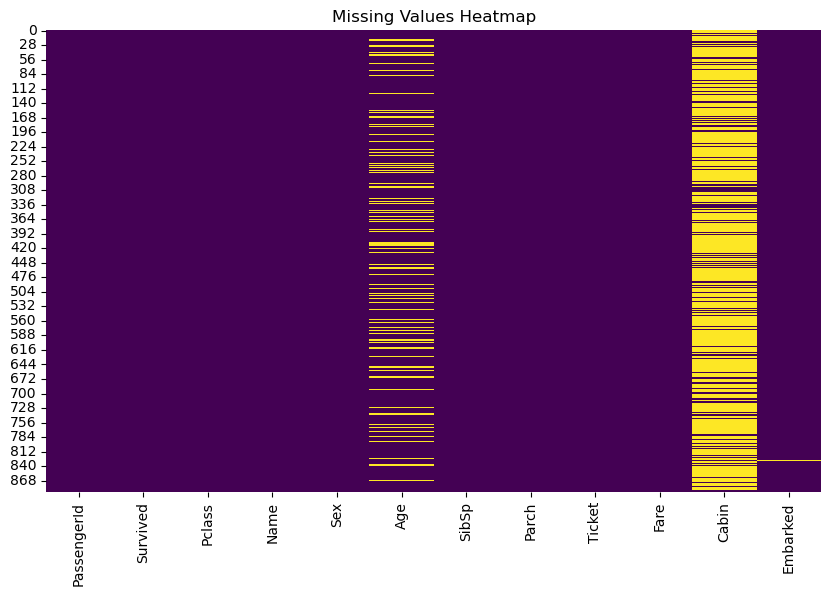

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [15]:
numeric_df = df.select_dtypes(include=["number"])

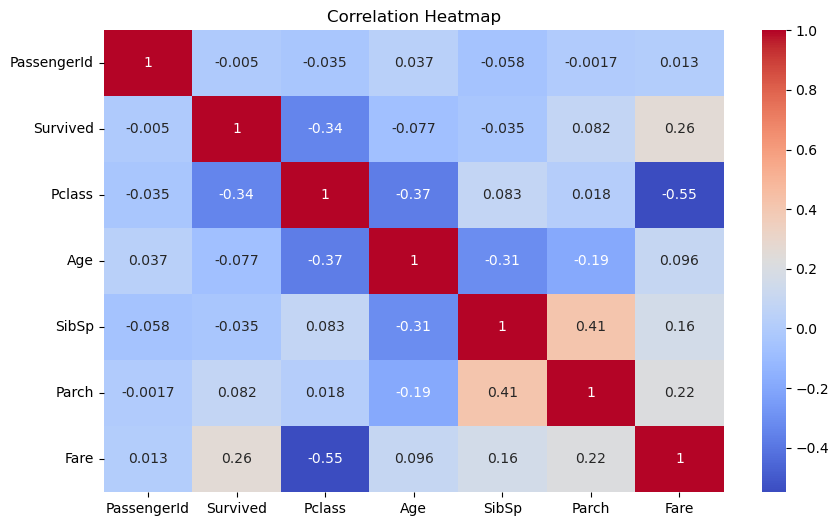

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
df.drop("Cabin", axis=1, inplace=True)

In [20]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [21]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [22]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

In [24]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [25]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [26]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize
0,0,3,0,22.0,1,0,7.2500,False,True,2
1,1,1,1,38.0,1,0,71.2833,False,False,2
2,1,3,1,26.0,0,0,7.9250,False,True,1
3,1,1,1,35.0,1,0,53.1000,False,True,2
4,0,3,0,35.0,0,0,8.0500,False,True,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,False,True,1
887,1,1,1,19.0,0,0,30.0000,False,True,1
888,0,3,1,28.0,1,2,23.4500,False,True,4
889,1,1,0,26.0,0,0,30.0000,False,False,1


In [27]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,True,2,0
1,1,1,1,38.0,1,0,71.2833,False,False,2,0
2,1,3,1,26.0,0,0,7.9250,False,True,1,1
3,1,1,1,35.0,1,0,53.1000,False,True,2,0
4,0,3,0,35.0,0,0,8.0500,False,True,1,1
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,False,True,1,1
887,1,1,1,19.0,0,0,30.0000,False,True,1,1
888,0,3,1,28.0,1,2,23.4500,False,True,4,0
889,1,1,0,26.0,0,0,30.0000,False,False,1,1


In [28]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,False,True,2,0
1,1,1,1,38.0,1,0,71.2833,False,False,2,0
2,1,3,1,26.0,0,0,7.9250,False,True,1,1
3,1,1,1,35.0,1,0,53.1000,False,True,2,0
4,0,3,0,35.0,0,0,8.0500,False,True,1,1


In [29]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
lr = LogisticRegression(max_iter=1000)

In [33]:
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
y_pred_lr = lr.predict(X_test)

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [36]:
accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [37]:
print("Precision:", precision_score(y_test, y_pred_lr))

Precision: 0.7714285714285715


In [38]:
print("Recall:", recall_score(y_test, y_pred_lr))

Recall: 0.7297297297297297


In [39]:
print("F1 Score:", f1_score(y_test, y_pred_lr))

F1 Score: 0.75


In [40]:
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[89 16]
 [20 54]]


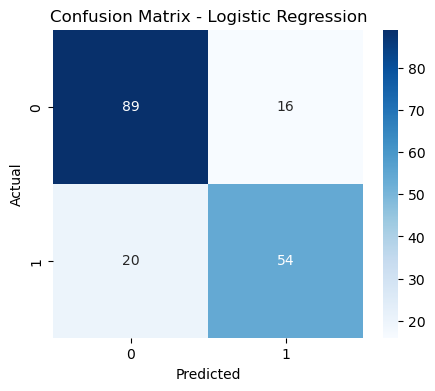

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [42]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [43]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [45]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7989
Decision Tree: 0.7933
Random Forest: 0.8324


In [46]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)
print("Best Accuracy:", results[best_model])

Best Model: Random Forest
Best Accuracy: 0.8324022346368715


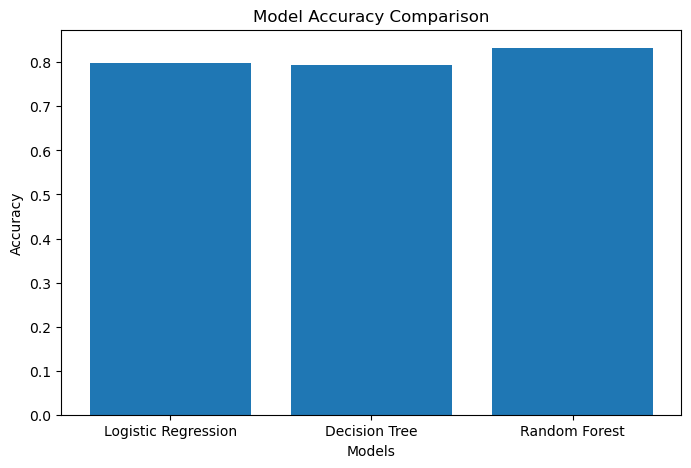

In [47]:
import matplotlib.pyplot as plt

models = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

      Feature  Importance
1         Sex    0.271105
5        Fare    0.262954
2         Age    0.248771
0      Pclass    0.077785
8  FamilySize    0.042982
3       SibSp    0.029954
7  Embarked_S    0.024830
4       Parch    0.020296
9     IsAlone    0.012035
6  Embarked_Q    0.009289


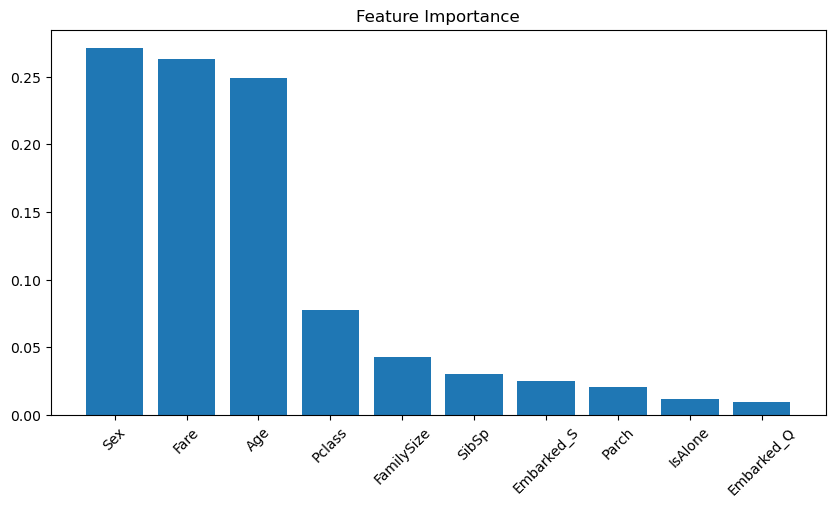

In [50]:
plt.figure(figsize=(10,5))
plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=45)
plt.title("Feature Importance")

plt.show()

In [51]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable


In [52]:
import joblib

In [53]:
joblib.dump(rf, "Titanic_Model.pkl")

['Titanic_Model.pkl']

In [54]:
loaded_model = joblib.load("Titanic_Model.pkl")

In [57]:
prediction = loaded_model.predict(X_test)

print(prediction)

[0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]


In [58]:
new_passenger = [[3, 0, 22, 1, 0, 7.25, 0, 1, 2, 0]]

prediction = loaded_model.predict(new_passenger)

print(prediction)

[0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Conclusion

In this project, I built a machine learning model to predict Titanic passenger survival.

I performed:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training
- Model Evaluation

Three models were trained:
- Logistic Regression
- Decision Tree
- Random Forest

After comparing their performance, Random Forest achieved the highest accuracy and was selected as the final model.

This project demonstrates the complete machine learning workflow, from preprocessing to prediction.